# Does the Finviz selection actually break out?

The backtest in `qbs/breakout.py` answers "what did the book earn". That number mixes
three things: the **selection** (did Finviz hand us names that break out?), the
**sizing**, and the **slot cap**. This notebook isolates the first one.

It measures a funnel, one row per pick:

```
selected -> had resistance overhead -> crossed it in the waiting window
         -> the cross held the confirmation -> the trade reached +1R
```

**The waiting window** is `wait_days` — how long after the weekend selection a first
breakout still counts. The default of 7 calendar days is exactly the week the watchlist
is meant to cover: a name that has not gone by the next selection has had its chance.
Section 8 sweeps it.

**+1R is the strategy's own definition of a breakout that worked.** It is exactly where
`breakout_signals` stops using the time stop and starts trailing. Reaching it is the
difference between a breakout and a poke.

---

### What this notebook can and cannot tell you

It runs on the lab's **cached daily closes**, not on hourly bars, so:

- The confirmation is two *sessions* rather than two hours — the daily analogue of the
  rule, and the closest honest reading at this resolution.
- High and Low are synthesised as the close-to-close envelope (`closes_to_bars`). That
  **understates** the true daily range, so ADR is smaller, R is smaller, stops are
  tighter, and the success rates below are **conservative**.
- The universe is the Nasdaq-100, not Finviz's full ~530-name output. The screen's
  rules are applied faithfully; the universe they run over is not the same one.

Swap in real hourly bars via `load_hourly()` and every number here re-derives.

## 1. Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))     # so `qbs` imports when run from notebooks/
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qbs.config import Config, BreakoutParams, FinvizScreenParams
from qbs.pipeline import run
from qbs.breakout import (breakout_funnel, funnel_summary, closes_to_bars,
                          finviz_watchlists)
from qbs.plotting import use_style, PALETTE

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
use_style()

## 2. Configuration

`WAIT_DAYS` is the waiting window. `N_WATCH` is how many names the weekend screen
carries into the week — the funnel is measured over all of them, not just the six the
book would have had room for.

In [2]:
cfg = Config()

WAIT_DAYS = 7      # calendar days after selection in which a first breakout counts
N_WATCH   = 20     # names on each weekend watchlist
OFFLINE   = True   # True -> cached CSVs only, no network

bp = BreakoutParams()          # causal levels, causal risk, lagged indicators
fp = FinvizScreenParams()      # the notebook screen's own defaults

print(f"waiting window: {WAIT_DAYS} days | watchlist: {N_WATCH} names")
print(f"confirmation:   {bp.confirm_hours} bars (= sessions on daily data)")

waiting window: 7 days | watchlist: 20 names
confirmation:   2 bars (= sessions on daily data)


## 3. Data

Daily closes for the Nasdaq-100 ranking universe, plus BOXX. Cached under `../data/`.

In [3]:
lab = run(cfg, offline=OFFLINE, fetch_universe=False,
          with_vix=False, with_book_vt=False, with_finviz=False)

uni  = lab.combined.drop(columns=["BOXX"])
safe = lab.prices["BOXX"]
print(f"{uni.shape[1]} names, {len(uni)} sessions, "
      f"{uni.index.min():%Y-%m-%d} to {uni.index.max():%Y-%m-%d}")

[universe] using NDX_FALLBACK (as of 2026-09). This is today's membership applied to all history: survivorship bias. See qbs/universe.py for how to supply point-in-time membership.
[universe] cache hit: 99/99 tickers, 2020-06-01 to 2026-09-08


98 names, 926 sessions, 2022-12-28 to 2026-09-08


## 4. The weekend watchlists

`finviz_watchlists` runs the screen with `n_hold=0` — every name that passes, in RS
order — rebuilt each Friday, and keeps the top `N_WATCH`.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


142 weekly selections, 2023-12-29 -> 2026-09-08
names per week: mean 19.8, min 12, max 20


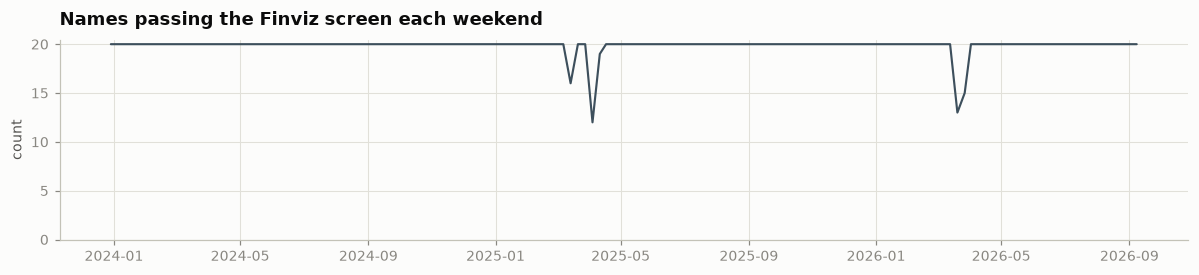

In [4]:
watchlists = finviz_watchlists(uni, safe, n_watch=N_WATCH, params=fp)

sizes = pd.Series({d: len(v) for d, v in watchlists.items()})
print(f"{len(watchlists)} weekly selections, {min(watchlists):%Y-%m-%d} -> {max(watchlists):%Y-%m-%d}")
print(f"names per week: mean {sizes.mean():.1f}, min {sizes.min()}, max {sizes.max()}")

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.plot(sizes.index, sizes.values, color=PALETTE["finviz"], linewidth=1.4)
ax.set_title("Names passing the Finviz screen each weekend")
ax.set_ylabel("count"); ax.set_ylim(bottom=0)
plt.tight_layout()

## 5. The funnel

One row per (selection date, ticker). This is the slow cell — it re-derives support and
resistance for every name on every weekend, causally.

In [5]:
bars   = closes_to_bars(uni)
funnel = breakout_funnel(bars, watchlists, p=bp, wait_days=WAIT_DAYS, progress=True)

print(f"\n{len(funnel):,} selection events over {funnel['selection_date'].nunique()} weeks")
funnel.head()

  [0/142] 2023-12-29


  [10/142] 2024-03-08


  [20/142] 2024-05-17


  [30/142] 2024-07-26


  [40/142] 2024-10-04


...

  [110/142] 2026-02-06


  [120/142] 2026-04-17


  [130/142] 2026-06-26


  [140/142] 2026-09-04

2,815 selection events over 142 weeks


,selection_date,ticker,rank,price,has_level,nearest_level,dist_pct,crossed,bars_to_cross,confirmed,entry_price,R,reached_1R,max_R,r_multiple,reason
0,2023-12-29,MSTR,1,63.161999,False,NaN,NaN,False,NaN,False,NaN,NaN,False,NaN,NaN,NaN
1,2023-12-29,NVDA,2,49.434132,True,49.854106,0.008496,False,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2,2023-12-29,META,3,350.878754,False,NaN,NaN,False,NaN,False,NaN,NaN,False,NaN,NaN,NaN
3,2023-12-29,CRWD,4,63.830002,True,65.019997,0.018643,False,NaN,False,NaN,NaN,False,NaN,NaN,NaN
4,2023-12-29,AMD,5,147.410004,False,NaN,NaN,False,NaN,False,NaN,NaN,False,NaN,NaN,NaN


,stage,n,of_selected,of_previous
0,selected,2815,100.0%,100.0%
1,had resistance overhead,1347,47.9%,47.9%
2,crossed it in the window,653,23.2%,48.5%
3,cross confirmed (an entry),370,13.1%,56.7%
4,reached +1R,186,6.6%,50.3%
5,closed profitable,142,5.0%,76.3%


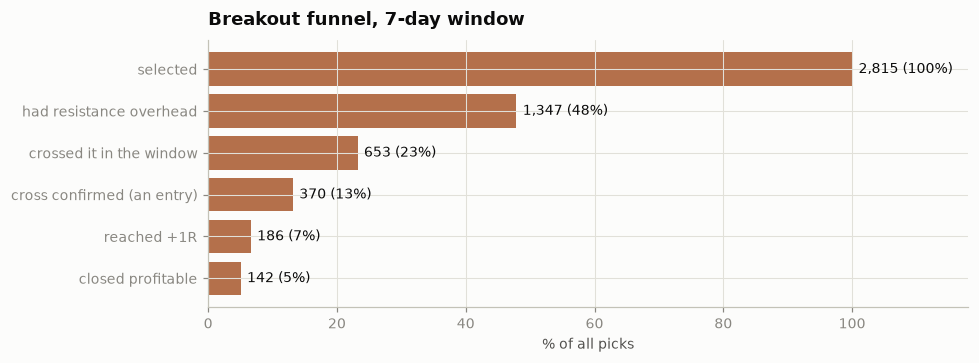

In [6]:
summary = funnel_summary(funnel)
display(summary.style.format({"of_selected": "{:.1%}", "of_previous": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(summary["stage"][::-1], summary["of_selected"][::-1] * 100,
        color=PALETTE["breakout"], alpha=0.85)
for y, (n, pct) in enumerate(zip(summary["n"][::-1], summary["of_selected"][::-1])):
    ax.text(pct * 100 + 1, y, f"{n:,} ({pct:.0%})", va="center", fontsize=9)
ax.set_xlabel("% of all picks"); ax.set_xlim(0, 118)
ax.set_title(f"Breakout funnel, {WAIT_DAYS}-day window")
plt.tight_layout()

## 6. The finding that matters: half the picks have nothing to break out through

The Finviz screen requires a name to be **within 10% of its 52-week high**. A name that
close to its high has, very often, already cleared every resistance level its chart
shows — there is nothing overhead to break.

So the selection rule and the entry rule are in tension: the screen is filtering *for*
names that have already broken out, and the breakout strategy needs names that have
not yet.

1,468 of 2,815 picks (52%) had no resistance level overhead at all.

For the ones that did, how far overhead the nearest level sat (%):
mean    2.35
25%     0.85
50%     1.82
75%     3.15


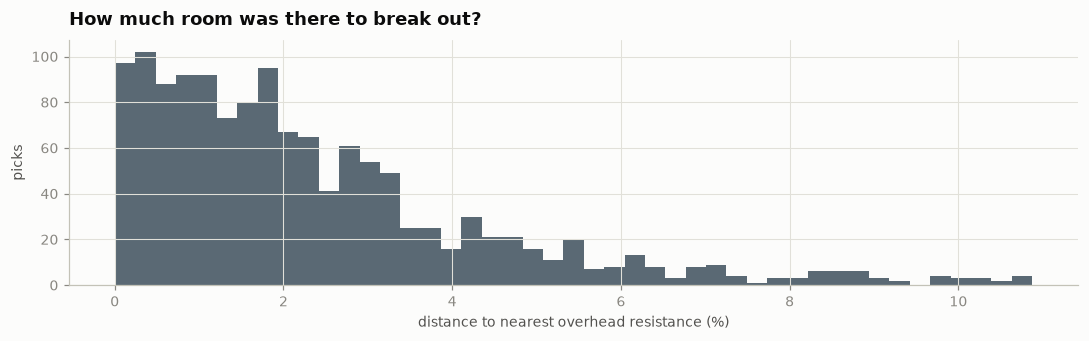

In [7]:
no_level = ~funnel["has_level"]
print(f"{no_level.sum():,} of {len(funnel):,} picks ({no_level.mean():.0%}) "
      f"had no resistance level overhead at all.\n")

overhead = funnel.loc[funnel["has_level"], "dist_pct"] * 100
print("For the ones that did, how far overhead the nearest level sat (%):")
print(overhead.describe()[["mean", "25%", "50%", "75%"]].round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(overhead.clip(upper=15), bins=45, color=PALETTE["finviz"], alpha=0.85)
ax.set_xlabel("distance to nearest overhead resistance (%)")
ax.set_ylabel("picks"); ax.set_title("How much room was there to break out?")
plt.tight_layout()

## 7. Conditional on confirming, what happened?

Of the picks that produced a real entry, how many worked.

In [8]:
conf = funnel[funnel["confirmed"]]
print(f"confirmed entries : {len(conf)}")
print(f"reached +1R       : {conf['reached_1R'].mean():.1%}")
print(f"closed profitable : {(conf['r_multiple'] > 0).mean():.1%}")
print(f"mean R multiple   : {conf['r_multiple'].mean():+.2f}R")
print(f"median R multiple : {conf['r_multiple'].median():+.2f}R")
print()
print(conf["reason"].fillna("still open").value_counts().to_string())

confirmed entries : 370
reached +1R       : 50.3%
closed profitable : 38.4%
mean R multiple   : +0.41R
median R multiple : -0.66R

reason
stop_R         153
time_or_ema    125
take_profit     91
still open       1


### ⚠️ The mean and the median disagree, and that is the whole story

A positive mean with a **negative median** means the edge lives entirely in the right
tail: most breakouts lose a little, a few win enormously. Check how concentrated that
is before believing any average on this page.

top 3 trades = 39% of all R earned across 369 confirmed trades
top 10 trades = 90%



,selection_date,ticker,rank,entry_price,r_multiple,reason
2322,2026-03-27,MRVL,3,109.428215,25.410849,take_profit
2338,2026-04-02,MRVL,4,128.458313,18.557856,take_profit
2335,2026-04-02,INTC,1,62.380001,15.174007,take_profit
1754,2025-09-05,MU,8,150.328735,12.468385,take_profit
22,2024-01-05,META,3,367.245056,11.441653,take_profit
2355,2026-04-10,MU,1,457.159698,11.336591,take_profit


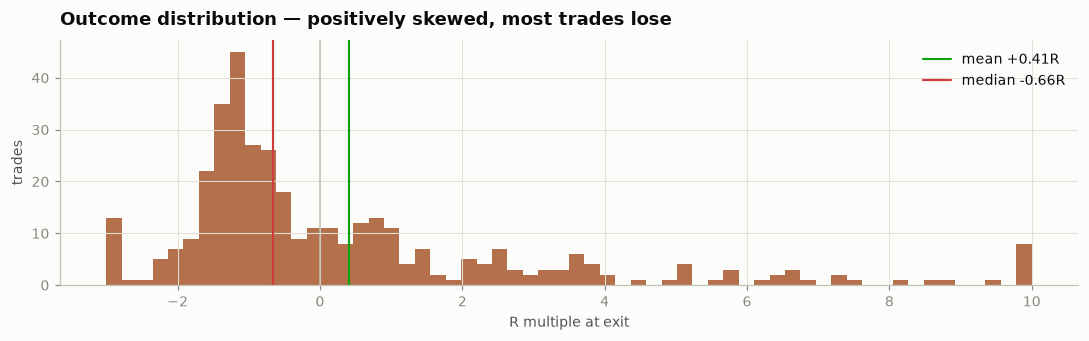

In [9]:
r = conf["r_multiple"].dropna().sort_values()
share = r[r > 0].sum()
print(f"top 3 trades = {r.nlargest(3).sum() / r.sum():.0%} of all R earned "
      f"across {len(r)} confirmed trades")
print(f"top 10 trades = {r.nlargest(10).sum() / r.sum():.0%}\n")
display(conf.nlargest(6, "r_multiple")[
    ["selection_date", "ticker", "rank", "entry_price", "r_multiple", "reason"]])

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(r.clip(-3, 10), bins=60, color=PALETTE["breakout"], alpha=0.85)
ax.axvline(0, color=PALETTE["axis"], linewidth=1)
ax.axvline(r.mean(), color=PALETTE["buy"], linewidth=1.4, label=f"mean {r.mean():+.2f}R")
ax.axvline(r.median(), color=PALETTE["sell"], linewidth=1.4, label=f"median {r.median():+.2f}R")
ax.set_xlabel("R multiple at exit"); ax.set_ylabel("trades"); ax.legend()
ax.set_title("Outcome distribution — positively skewed, most trades lose")
plt.tight_layout()

## 8. Does the Finviz RS rank predict breakout success?

The screen ranks its output. If that ranking carries information, the top-ranked names
should break out better — and it is worth knowing *which* part of the outcome it
predicts.

In [10]:
funnel["rank_bucket"] = pd.cut(funnel["rank"], [0, 5, 10, 15, 20],
                               labels=["1-5", "6-10", "11-15", "16-20"])

by_rank = funnel.groupby("rank_bucket", observed=True).agg(
    picks=("ticker", "size"),
    has_level=("has_level", "mean"),
    crossed=("crossed", "mean"),
    confirmed=("confirmed", "mean"),
    reached_1R=("reached_1R", "mean"),
)
conf_rank = funnel[funnel["confirmed"]].groupby("rank_bucket", observed=True)["r_multiple"].agg(
    entries="size", mean_R="mean", median_R="median",
    win_rate=lambda s: (s > 0).mean(),
    trimmed_R=lambda s: s.sort_values().iloc[1:-1].mean() if len(s) > 4 else np.nan,
)
display(by_rank.join(conf_rank).style.format({
    "has_level": "{:.1%}", "crossed": "{:.1%}", "confirmed": "{:.1%}",
    "reached_1R": "{:.1%}", "win_rate": "{:.1%}",
    "mean_R": "{:+.2f}", "median_R": "{:+.2f}", "trimmed_R": "{:+.2f}"}))

,picks,has_level,crossed,confirmed,reached_1R,entries,mean_R,median_R,win_rate,trimmed_R
rank_bucket,,,,,,,,,,
1-5,710,37.3%,18.6%,11.8%,6.8%,84,+1.37,-0.89,39.3%,+1.21
6-10,710,45.9%,22.4%,13.2%,7.3%,94,+0.21,-0.62,38.3%,+0.11
11-15,705,50.2%,23.0%,11.5%,5.4%,81,+0.14,-0.64,37.0%,+0.11
16-20,690,58.3%,29.0%,16.1%,7.0%,111,+0.03,-0.66,38.7%,+0.07


Read that table in two columns, because they say opposite things.

`has_level` **rises** with rank — the strongest names are the least likely to have
anything overhead, for exactly the reason in section 6. The best picks are the least
tradeable by this entry.

`mean_R` **falls** with rank — when a top-ranked name does break out, it goes further.
But check `win_rate` and `median_R` before acting on that: if the win rate is flat
across buckets, the rank is not predicting *whether* you win, only the size of the
tail, and a tail estimated from this few trades is not something to size a book on.

### 8b. ⚠️ Before you act on the top bucket

The `mean_R` column above invites one specific misreading: *"trade only the top 5 and
expect +1.37R."* You cannot. Three separate reasons, each sufficient on its own.

**First, R is not return.** It is profit in units of the risk taken, on a trade that
only happens when a pick confirms — about one pick in eight. Convert it before
comparing it to anything.

In [11]:
conf = funnel[funnel["confirmed"]].dropna(subset=["r_multiple"]).copy()
r_pct = conf["R"] / conf["entry_price"] * 100
print(f"median 1R      = {r_pct.median():.2f}% of the entry price")
print(f"so +1.37R      = {1.37 * r_pct.median():.1f}% of the POSITION, not of the book")
print(f"confirm rate   = {funnel.loc[funnel['rank'] <= 5, 'confirmed'].mean():.1%} "
      f"of top-5 picks ever become a trade")

median 1R      = 2.85% of the entry price
so +1.37R      = 3.9% of the POSITION, not of the book
confirm rate   = 11.8% of top-5 picks ever become a trade


**Second, the estimate is dominated by a handful of trades.** Drop the best few and
it collapses.

In [12]:
top5 = conf.loc[conf["rank"] <= 5, "r_multiple"].sort_values()
for k in range(6):
    kept = top5.iloc[:len(top5) - k] if k else top5
    print(f"  drop top {k}: n={len(kept)}, mean {kept.mean():+.2f}R")

rng = np.random.default_rng(0)
boot = np.array([rng.choice(top5.values, len(top5), replace=True).mean()
                 for _ in range(20_000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"\nbootstrap 95% CI on the mean: [{lo:+.2f}R, {hi:+.2f}R]")
print(f"median trade: {top5.median():+.2f}R  <- most top-5 breakouts LOSE")

  drop top 0: n=84, mean +1.37R
  drop top 1: n=83, mean +1.08R
  drop top 2: n=82, mean +0.87R
  drop top 3: n=81, mean +0.69R
  drop top 4: n=80, mean +0.56R
  drop top 5: n=79, mean +0.42R



bootstrap 95% CI on the mean: [+0.35R, +2.53R]
median trade: -0.89R  <- most top-5 breakouts LOSE


**Third, it is one regime and a few tickers.** Split it by year and by name.

In [13]:
conf["yr"] = conf["selection_date"].dt.year
conf["top5"] = conf["rank"] <= 5
display(conf.groupby(["yr", "top5"])["r_multiple"].agg(n="size", mean="mean").unstack().round(2))

t5 = conf[conf["top5"]]
by_ticker = t5.groupby("ticker")["r_multiple"].agg(n="size", total="sum").sort_values("total", ascending=False)
display(by_ticker.head(5).round(2))
print(f"top 3 tickers = {by_ticker['total'].head(3).sum() / t5['r_multiple'].sum():.0%} "
      f"of all R in the top-5 bucket")

n        mean      
top5 False True  False True 
yr                          
2024   115    49  0.14  0.86
2025   104    24  0.13  0.26
2026    66    11  0.08  6.05

,n,total
ticker,,
MRVL,2,43.97
NVDA,7,19.18
MU,5,15.77
APP,10,14.39
META,6,10.02


top 3 tickers = 69% of all R in the top-5 bucket


**What the data does support.** The gap is not noise — a permutation test on the rank
label rejects, and the direction holds in both halves of the sample and in every year.
Concentrating on the top-ranked names genuinely improves the book.

What it does *not* support is the **magnitude**. `+1.37R` is a point estimate of a fat
tail, and the tail is one semiconductor trade in one year.

In [14]:
rest = conf.loc[~conf["top5"], "r_multiple"]
obs = top5.mean() - rest.mean()
allv = conf["r_multiple"].values
n1 = len(top5)
perm = np.array([(lambda x: x[:n1].mean() - x[n1:].mean())(rng.permutation(allv))
                 for _ in range(20_000)])
print(f"observed gap {obs:+.2f}R, permutation p = {(np.abs(perm) >= abs(obs)).mean():.3f}")

mid = conf["selection_date"].quantile(0.5)
for label, part in (("first half ", conf[conf["selection_date"] <= mid]),
                    ("second half", conf[conf["selection_date"] > mid])):
    a, b = part[part["top5"]]["r_multiple"], part[~part["top5"]]["r_multiple"]
    print(f"  {label}: top5 n={len(a)} mean {a.mean():+.2f}R | rest n={len(b)} mean {b.mean():+.2f}R")

observed gap +1.25R, permutation p = 0.002
  first half : top5 n=51 mean +0.76R | rest n=134 mean +0.16R
  second half: top5 n=33 mean +2.31R | rest n=151 mean +0.09R


### 8c. The honest version: just trade it

Rather than extrapolating a per-trade average, run the book on a shorter watchlist and
read the portfolio number. This is the only figure that answers "what would I have
made", because it accounts for the confirm rate, the slot cap and the cash in between.

In [15]:
from qbs.breakout import weekly_breakout_book
from qbs.config import WeeklyBookParams
from qbs.metrics import summarise

for label, ws, ns in (("top 5 only", 5, 5), ("top 10", 10, 6), ("top 20 (base)", 20, 6)):
    sub = {d: names[:ws] for d, names in watchlists.items()}
    bk = weekly_breakout_book(bars, sub, safe, bp,
                              WeeklyBookParams(n_slots=ns, watchlist_size=ws))
    s = summarise(bk.result, rf=lab.rf)
    closed = bk.trades[bk.trades["exit_time"].notna()]
    print(f"{label:<14} trades {len(bk.trades):>3}  meanR {closed['R_multiple'].mean():+.2f}  "
          f"CAGR {s['CAGR']:+6.1%}  vol {s['Ann. vol']:5.1%}  "
          f"maxDD {s['Max drawdown']:6.1%}  exposure {s['Avg risk exposure']:.0%}")

print(f"\nbuy & hold QQQ, same window: CAGR "
      f"{summarise(lab.results['bh_qqq'], rf=lab.rf)['CAGR']:+.1%}")

top 5 only     trades  71  meanR +2.20  CAGR +36.1%  vol 16.8%  maxDD -10.7%  exposure 31%


top 10         trades 130  meanR +1.42  CAGR +36.2%  vol 18.5%  maxDD -12.6%  exposure 42%


top 20 (base)  trades 212  meanR +0.81  CAGR +24.9%  vol 18.5%  maxDD -18.9%  exposure 65%

buy & hold QQQ, same window: CAGR +22.2%


A shorter watchlist does look better here — more return, lower drawdown, a third of
the exposure. But **survivorship bias hits this result harder than anything else on the
page**, and in a way you can state mechanically:

> The universe is *today's* Nasdaq-100. The top-RS names in it are disproportionately
> the names that went on to become large — which is why they are in the index today.
> Ranking by RS inside a survivorship-biased universe selects for exactly that.

The names carrying the top-5 bucket are the ones that argument predicts. Treat the
concentration result as a hypothesis to test on point-in-time membership, not as a
finding.

## 9. How quickly does the first breakout arrive?

This is what sets the waiting window.

mean    2.2
50%     2.0
75%     3.0
max     5.0


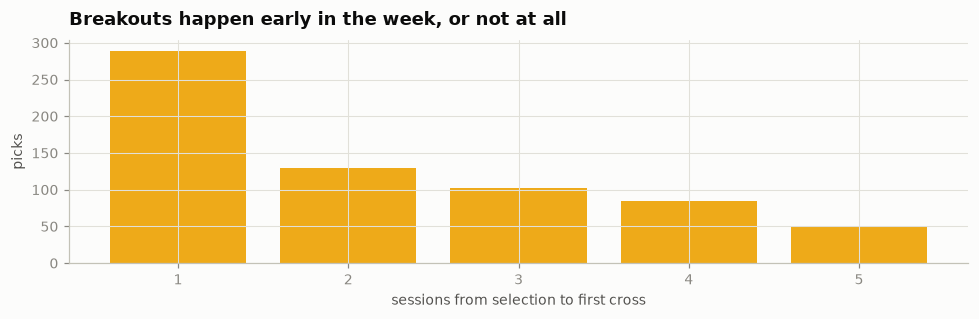

In [16]:
crossed = funnel[funnel["crossed"]]
print(crossed["bars_to_cross"].describe()[["mean", "50%", "75%", "max"]].round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 3.0))
vc = crossed["bars_to_cross"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=PALETTE["momentum"], alpha=0.9)
ax.set_xlabel("sessions from selection to first cross")
ax.set_ylabel("picks"); ax.set_title("Breakouts happen early in the week, or not at all")
plt.tight_layout()

## 10. Sensitivity to the waiting window

If most of the success rate comes from waiting longer than a week, the weekly
re-selection is throwing away trades. If the curve flattens, one week is enough.

Slow — it re-runs the whole funnel per value.

,wait_days,crossed,confirmed,reached_1R,entries,mean_R,median_R
0,3,9.3%,4.4%,2.0%,125,+0.30,-0.69
1,5,17.7%,8.9%,4.5%,250,+0.42,-0.67
2,7,23.2%,13.1%,6.6%,370,+0.41,-0.66
3,10,24.8%,14.3%,7.1%,403,+0.41,-0.67
4,14,29.3%,18.2%,8.8%,511,+0.26,-0.72
5,21,32.6%,20.9%,10.1%,588,+0.22,-0.74


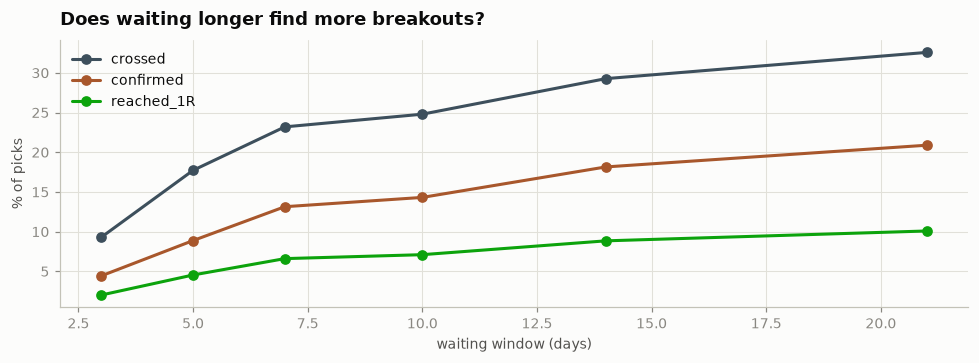

In [17]:
rows = []
for wd in [3, 5, 7, 10, 14, 21]:
    f_wd = breakout_funnel(bars, watchlists, p=bp, wait_days=wd)
    c = f_wd[f_wd["confirmed"]]
    rows.append({"wait_days": wd,
                 "crossed": f_wd["crossed"].mean(),
                 "confirmed": f_wd["confirmed"].mean(),
                 "reached_1R": f_wd["reached_1R"].mean(),
                 "entries": len(c),
                 "mean_R": c["r_multiple"].mean(),
                 "median_R": c["r_multiple"].median()})

wait = pd.DataFrame(rows)
display(wait.style.format({"crossed": "{:.1%}", "confirmed": "{:.1%}",
                           "reached_1R": "{:.1%}", "mean_R": "{:+.2f}",
                           "median_R": "{:+.2f}"}))

fig, ax = plt.subplots(figsize=(9, 3.4))
for col, colour in (("crossed", "finviz"), ("confirmed", "breakout"), ("reached_1R", "buy")):
    ax.plot(wait["wait_days"], wait[col] * 100, marker="o",
            color=PALETTE[colour], label=col)
ax.set_xlabel("waiting window (days)"); ax.set_ylabel("% of picks")
ax.legend(); ax.set_title("Does waiting longer find more breakouts?")
plt.tight_layout()

## 11. What this does and does not establish

**Establishes.** The shape of the funnel: where picks are lost, how fast breakouts
arrive, and whether the screen's own ranking separates outcomes. Those are structural
and a sample this size supports them.

**Does not establish.** That the strategy makes money. The R distribution is
tail-driven — check the top-3 share printed in section 7 — so the mean is an estimate
of a fat tail from a handful of trades, in one regime, on one universe.

Specific caveats:

- **Close-only bars.** High/Low are the close-to-close envelope, which understates the
  true range, so stops are tighter here than they would be live. Conservative, but not
  the real number. Re-run on `load_hourly()` bars.
- **Nasdaq-100, not Finviz's real output.** The screen's ~530-name universe is not
  point-in-time reproducible; this uses the 99 NDX names, which are larger, more
  liquid, and more correlated than what the live screen returns.
- **Survivorship bias** in the NDX membership list — see the warning at the top of the
  main README. It flatters everything here.
- **One regime.** Roughly two and a half years, with a semiconductor melt-up in it. The
  biggest winners in section 7 are all from that trade.